## Object Detection

#### **What is object detection?**

Object detection is a computer vision technique that help identify specific objects within an image

Object detection depends upon two core tasks

- Classification : Identification of objects within an image
- Localization   :  Drawing an axis-aligned bounding box (defined by coordinates like $([x, y, \text{width}, \text{height}])$ around the object.

#### **What could be an architecture to do this task?**

A straight-forward approach to this task is training a Convolutional Neural Network (CNN) with a multi-headed output: one head for classification and another for localization.

The Workflow:
- Train a CNN model.
- Extract the flattened layer feature map.
- Pass the features simultaneously through the classification and localization heads.
- Verify that the classification and localization outputs correspond correctly to the same object.


The above mentioned basic CNN architecture , YOLO(You Only Look Once) , SSD(Single Shot Multi-Box Detector) all come under Single - Stage Detector Architectures simply because they detect the object in a single forward pass.

**Note** : Single - Stage detector architectures are fast but they can struggle with precision, particularly on small or overlapping objects.

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQOsb2zAHaBNja4vHJOk9Hy3ezK_xuiCsJKTA&s" height = 400 width = 864 />

#### **How Do We Prioritize Precision**?
Single-stage detectors often struggle with precision, which indirectly creates a lot of false positives. To overcome the problem of false positives, you can implement the following strategies:

**1.Control the Confidence Level**
You can filter out low-certainty predictions by raising the model's confidence threshold. By demanding a higher confidence score before a bounding box is displayed, you eliminate noisy, incorrect detections.

**2.Add a Rechecking Head (Two-Stage Architecture)**
You can introduce a dedicated "rechecking head" by moving to a two-stage detector architecture (like Faster R-CNN).

- Stage 1 : acts as a quick filter to propose potential object regions.

- Stage 2 : acts as the rechecking mechanism, meticulously evaluating only those proposed regions to confirm exactly what and where the objects are.


<img src="https://www.mdpi.com/remotesensing/remotesensing-13-00089/article_deploy/html/images/remotesensing-13-00089-g002.png" width = 1000 height = 400 />

#### Lets us design the basic Single-Stage Architecture using pytorch before we move ahead and explore modules to ease our task

In [1]:
#Import necessary modules
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
import torchvision.models as models
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm.notebook import tqdm



**Source:** [Check out this dataset on Kaggle](https://www.kaggle.com/datasets/mehmetcubukcu/weapon-detection)

**Note**: The dataset has not been included in this repository please download the dataset and save it in the following folder **./weapon-detection** to avoid any path conflicts

In [4]:
# =====================================================================
# 1. SETUP GLOBAL CONFIGURATIONS & INITIAL CUSTOMIZATION
# =====================================================================
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
import torchvision.models as models
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Training Constants
NUM_EPOCHS = 20
BATCH_SIZE = 8
LEARNING_RATE = 0.0003
IMG_SIZE = 448

# Update tracking mapping configurations to your specific categorical dataset length
CUSTOM_CLASSES = ["pistol", "smartphone", "knife", "monedero", "billete", "tarjeta"]
num_classes = len(CUSTOM_CLASSES)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =====================================================================
# 2. DATASET DEFINITION (LOG-SPACE CONVERSION FOR EXPONENTIAL SIZES)
# =====================================================================
class SimpleDetectionDataset(Dataset):
    def __init__(self, split_dir, img_size=448):
        self.img_dir = os.path.join(split_dir, 'images')
        self.label_dir = os.path.join(split_dir, 'labels')
        # Filter files safely using appropriate operational image configurations
        if os.path.exists(self.img_dir):
            self.img_names = [f for f in os.listdir(self.img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
        else:
            self.img_names = []
        
        # Standard Visual Transforms
        self.transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        transformed_image = self.transform(image)

        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(self.label_dir, label_name)
        
        class_id = 0
        bbox_target = [0.0, 0.0, 0.0, 0.0] 

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()
                if lines:
                    parts = lines[0].strip().split()
                    if len(parts) == 5:
                        class_id = int(parts[0])
                        x_c, y_c, w, h = [float(val) for val in parts[1:]]
                        
                        # Apply transformation: standard log scaling stabilizes training bounds
                        w_log = torch.log(torch.tensor(w) + 1e-6).item()
                        h_log = torch.log(torch.tensor(h) + 1e-6).item()
                        
                        bbox_target = [x_c, y_c, w_log, h_log]

        return transformed_image, torch.tensor(class_id, dtype=torch.long), torch.tensor(bbox_target, dtype=torch.float32)

# =====================================================================
# 3. SINGLE-STAGE TWO-HEADED RESNET REGRESSION BACKBONE
# =====================================================================
class SingleStageDetector(nn.Module):
    def __init__(self, num_classes):
        super(SingleStageDetector, self).__init__()
        
        # Leverage generic ResNet feature map extraction layer
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2]) 
        self.pool = nn.AdaptiveAvgPool2d((1, 1)) 
        
        # Class Allocation Prediction Head
        self.class_head = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
        
        # Boundary Position Bounding Head
        self.box_center_head = nn.Linear(512, 2)  # Generates absolute coordinate center offsets [x, y]
        self.box_size_head = nn.Linear(512, 2)    # Generates log dimensions [width, height]

    def forward(self, x):
        features = self.backbone(x)      
        features = self.pool(features)   
        features = torch.flatten(features, 1) 
        
        class_logits = self.class_head(features)
        
        # Sigmoid forces centers squarely inside valid coordinate zones [0, 1]
        pred_centers = torch.sigmoid(self.box_center_head(features))
        pred_sizes = self.box_size_head(features)
        
        # Package coordinates into a single linear block mapping sequence
        bbox_coords = torch.cat([pred_centers, pred_sizes], dim=1)
        
        return class_logits, bbox_coords

# =====================================================================
# 4. DATA PIPELINE AND INITIALIZATION SETUP
# =====================================================================
# Define paths relative to configuration directory layout requirements
train_dataset = SimpleDetectionDataset(split_dir="./weapon-detection/train/")
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

model = SingleStageDetector(num_classes=num_classes)
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
class_criterion = nn.CrossEntropyLoss()
box_criterion = nn.MSELoss()

# =====================================================================
# 5. SIMPLIFIED MULTI-TASK LOG-SPACE TRAINING PIPELINE
# =====================================================================
print("--> Training initialization sequence active...")
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    
    for images, labels, bboxes in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        bboxes = bboxes.to(device)
        
        optimizer.zero_grad()
        
        # Execute single forward pass
        pred_classes, pred_boxes = model(images)
        
        # Compute individual optimization variables
        loss_cls = class_criterion(pred_classes, labels)
        loss_box = box_criterion(pred_boxes, bboxes)
        
        # Combine parameters sequentially with appropriate magnitude balancing factors
        total_loss = loss_cls + (15.0 * loss_box)
        
        total_loss.backward()
        optimizer.step()
        running_loss += total_loss.item() * images.size(0)
        
    if len(train_dataset) > 0:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Aggregate Iteration Loss: {running_loss / len(train_dataset):.4f}")
    else:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] completed. Pipeline checked (Dataset directory empty or processing configuration requirements).")

print("--> Training Complete.")

Using device: cuda
--> Training initialization sequence active...
Epoch [1/20] | Aggregate Iteration Loss: 2.8517
Epoch [2/20] | Aggregate Iteration Loss: 1.3419
Epoch [3/20] | Aggregate Iteration Loss: 1.0054
Epoch [4/20] | Aggregate Iteration Loss: 0.7794
Epoch [5/20] | Aggregate Iteration Loss: 0.6567
Epoch [6/20] | Aggregate Iteration Loss: 0.5215
Epoch [7/20] | Aggregate Iteration Loss: 0.4989
Epoch [8/20] | Aggregate Iteration Loss: 0.4726
Epoch [9/20] | Aggregate Iteration Loss: 0.4386
Epoch [10/20] | Aggregate Iteration Loss: 0.4220
Epoch [11/20] | Aggregate Iteration Loss: 0.3433
Epoch [12/20] | Aggregate Iteration Loss: 0.2966
Epoch [13/20] | Aggregate Iteration Loss: 0.2406
Epoch [14/20] | Aggregate Iteration Loss: 0.3209
Epoch [15/20] | Aggregate Iteration Loss: 0.2816
Epoch [16/20] | Aggregate Iteration Loss: 0.1966
Epoch [17/20] | Aggregate Iteration Loss: 0.2483
Epoch [18/20] | Aggregate Iteration Loss: 0.2255
Epoch [19/20] | Aggregate Iteration Loss: 0.2388
Epoch [20/20

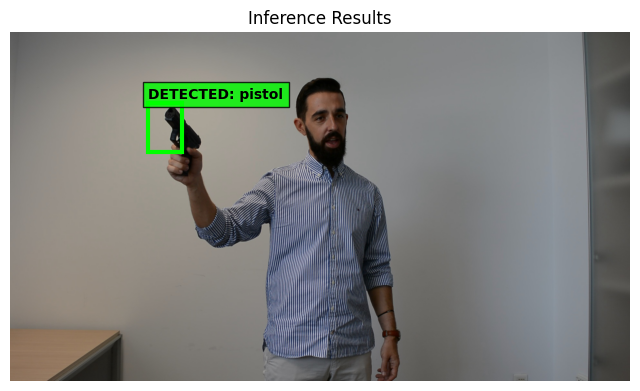

In [5]:
# =====================================================================
# 6. INFERENCE & EXPONENTIAL DECODING VISUALIZATION
# =====================================================================
model.eval()

# checking test results
test_img_path = "./weapon-detection/test/images/img483.jpg" 

if not os.path.exists(test_img_path):
    print(f"Execution notice: Update the 'test_img_path' string variable to read a real test file.")
else:
    orig_img = Image.open(test_img_path).convert("RGB")
    orig_w, orig_h = orig_img.size
    
    transform_eval = T.Compose([
        T.Resize((448, 448)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    tensor_img = transform_eval(orig_img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        pred_cls_logits, pred_box = model(tensor_img)
        pred_cls_logits = pred_cls_logits.cpu()
        pred_box = pred_box.cpu().squeeze(0).numpy()
        
    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(orig_img, cmap='gray')
    
    # Extract prediction parameters
    x_c = pred_box[0]
    y_c = pred_box[1]
    
    #INVERSE MATH: Decode the width/height out of log space back to normal 0-1 scale using exponential
    w = torch.exp(torch.tensor(pred_box[2])).item()
    h = torch.exp(torch.tensor(pred_box[3])).item()
    
    # Hard-clip the resulting width/height safely at the very end *only* for graphic boundaries
    w = min(max(w, 0.01), 1.0)
    h = min(max(h, 0.01), 1.0)
    
    # Convert global ratios into direct image coordinates
    box_w = w * orig_w
    box_h = h * orig_h
    box_x = (x_c - w / 2) * orig_w
    box_y = (y_c - h / 2) * orig_h
    
    cls_id = torch.argmax(pred_cls_logits, dim=1).item()
    label = CUSTOM_CLASSES[cls_id]
    
    rect = patches.Rectangle(
        (box_x, box_y), box_w, box_h, 
        linewidth=3, edgecolor='lime', facecolor='none'
    )
    ax.add_patch(rect)
    
    plt.text(
        box_x, box_y - 12, 
        f"DETECTED: {label}", 
        color='black', weight='bold', bbox=dict(facecolor='lime', alpha=0.8)
    )
    
    plt.axis('off')
    plt.title("Inference Results", fontsize=12)
    plt.show()